## Dataset and DataLoader

In [16]:
import torch
import torchvision
from torchvision.transforms import v2

# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize((0.5,), (0.5,)),
    ]
)

training_set = torchvision.datasets.FashionMNIST(
    "./data", train=True, transform=transform, download=True
)
validation_set = torchvision.datasets.FashionMNIST(
    "./data", train=False, transform=transform, download=True
)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(
    validation_set, batch_size=4, shuffle=True
)

# Class labels
classes = (
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
)

# Report split sizes
print(f"Training set has {len(training_set)} instances")
print(f"Validation set has {len(validation_set)} instances")

Training set has 60000 instances
Validation set has 10000 instances


Ankle Boot  Trouser  T-shirt/top  Coat


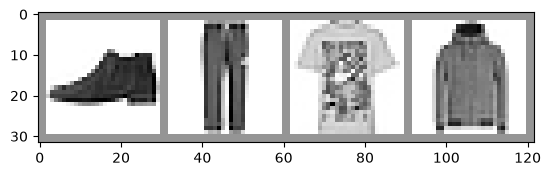

In [17]:
import matplotlib.pyplot as plt
import numpy as np


# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))


dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print("  ".join(classes[labels[j]] for j in range(4)))

## The Model

In [18]:
import torch.nn as nn
import torch.nn.functional as F


# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = GarmentClassifier()

## Loss Function

In [19]:
loss_fn = torch.nn.CrossEntropyLoss()

# NB: Loss functions expect data in batches, so we're creating batches of 4
# Represents the model's confidence in each of the 10 classes for a given input
dummy_outputs = torch.rand(4, 10)
# Represents the correct class among the 10 being tested
dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print(f"Total loss for this batch: {loss.item()}")

tensor([[0.6220, 0.3897, 0.3590, 0.9979, 0.3676, 0.3096, 0.6552, 0.3838, 0.3677,
         0.3908],
        [0.5568, 0.1686, 0.1297, 0.0030, 0.5832, 0.0427, 0.7098, 0.1597, 0.2558,
         0.2773],
        [0.6387, 0.6977, 0.5723, 0.9664, 0.9257, 0.6688, 0.7130, 0.5491, 0.0256,
         0.7469],
        [0.8142, 0.2436, 0.2781, 0.8556, 0.5803, 0.4843, 0.6081, 0.0280, 0.0021,
         0.5906]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.4431543350219727


## Optimizer

In [20]:
# Optimizers specified in the torch.optim package
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

## The Training Loop

In [21]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.0
    last_loss = 0.0

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000  # loss per batch
            print(f"  batch {i + 1} loss: {last_loss}")
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar("Loss/train", last_loss, tb_x)
            running_loss = 0.0

    return last_loss

## Per-Epoch Activity

In [22]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
writer = SummaryWriter(f"runs/fashion_trainer_{timestamp}")
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.0

for epoch in range(EPOCHS):
    print(f"EPOCH {epoch_number + 1}:")

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)

    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print(f"LOSS train {avg_loss} valid {avg_vloss}")

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars(
        "Training vs. Validation Loss",
        {"Training": avg_loss, "Validation": avg_vloss},
        epoch_number + 1,
    )
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"model_{timestamp}_{epoch_number}"
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 1.7916026393026114
  batch 2000 loss: 0.876673922445625
  batch 3000 loss: 0.7262493171319365
  batch 4000 loss: 0.6660118549494073
  batch 5000 loss: 0.6198806841343175
  batch 6000 loss: 0.575192119397223
  batch 7000 loss: 0.557175118407933
  batch 8000 loss: 0.5212030386046972
  batch 9000 loss: 0.49716084959020374
  batch 10000 loss: 0.49804807141504714
  batch 11000 loss: 0.45254497982433534
  batch 12000 loss: 0.45860087394888976
  batch 13000 loss: 0.440300337285611
  batch 14000 loss: 0.42053158202885244
  batch 15000 loss: 0.4249060895196453
LOSS train 0.4249060895196453 valid 0.4161452651023865
EPOCH 2:
  batch 1000 loss: 0.39889150842494564
  batch 2000 loss: 0.402194659775123
  batch 3000 loss: 0.3963168912201654
  batch 4000 loss: 0.40134907224180644
  batch 5000 loss: 0.3818835045266896
  batch 6000 loss: 0.3812029121608357
  batch 7000 loss: 0.3621741603881819
  batch 8000 loss: 0.37511241289356256
  batch 9000 loss: 0.37198467170563526
  bat

In [30]:
PATH = "./checkpoints/GarmentClassifier.pth"

torch.save(model.state_dict(), PATH)

saved_model = GarmentClassifier()
saved_model.load_state_dict(torch.load(PATH))

<All keys matched successfully>